In [2]:
import pandas as pd
weather=pd.read_csv(r"C:\Users\Biju Nambiar\Downloads\india_2000_2024_daily_weather.csv")
weather.head()
aqi=pd.read_csv(r"C:\Users\Biju Nambiar\OneDrive\Desktop\da project\project 3(major)\dataset\city_day.csv")
aqi.head()
aqi.shape
weather.shape
weather.isnull().sum()
aqi.isnull().sum()
aqi=aqi.drop(['Benzene','Toluene','Xylene','AQI_Bucket'], axis=1)
aqi=aqi.fillna(aqi.mean(numeric_only=True))
aqi.info()
weather.head()
aqi['Date'].min(), aqi['Date'].max()
weather['date'].min(), weather['date'].max()
aqi.isnull().sum()
weather.rename(columns={'city': 'City','date':'Date'},inplace=True)
weather.head()
weather.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29531 entries, 0 to 29530
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   City    29531 non-null  object 
 1   Date    29531 non-null  object 
 2   PM2.5   29531 non-null  float64
 3   PM10    29531 non-null  float64
 4   NO      29531 non-null  float64
 5   NO2     29531 non-null  float64
 6   NOx     29531 non-null  float64
 7   NH3     29531 non-null  float64
 8   CO      29531 non-null  float64
 9   SO2     29531 non-null  float64
 10  O3      29531 non-null  float64
 11  AQI     29531 non-null  float64
dtypes: float64(10), object(2)
memory usage: 2.7+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 91320 entries, 0 to 91319
Data columns (total 12 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   City                         91320 non-null  object 
 1   Date                         913

In [3]:
weather['Date']=pd.to_datetime(weather['Date'])
aqi['Date']=pd.to_datetime(aqi['Date'])
print(aqi['Date'].min(),aqi['Date'].max())
print(weather['Date'].min(),weather['Date'].max())
weather.head()

weather = weather.drop([
    'apparent_temperature_max',
    'apparent_temperature_min',
    'rain_sum',
    'weather_code',
    'wind_direction_10m_dominant'
], axis=1, errors='ignore')
print(weather.columns)


2015-01-01 00:00:00 2020-07-01 00:00:00
2000-01-01 00:00:00 2024-12-31 00:00:00
Index(['City', 'Date', 'temperature_2m_max', 'temperature_2m_min',
       'precipitation_sum', 'wind_speed_10m_max', 'wind_gusts_10m_max'],
      dtype='object')


In [4]:
print(weather.columns)
weather.info()
print(aqi['Date'].min(),aqi['Date'].max())
merged=pd.merge(aqi,weather,on=['City','Date'],how='inner')
merged.head()
merged.isnull().sum()
corr = merged.select_dtypes(include='number').corr()
print(corr)
corr["AQI"].sort_values(ascending=False)

#Pollution gases increase AQI, while weather factors like wind and rainfall help reduce pollution levels.



Index(['City', 'Date', 'temperature_2m_max', 'temperature_2m_min',
       'precipitation_sum', 'wind_speed_10m_max', 'wind_gusts_10m_max'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 91320 entries, 0 to 91319
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   City                91320 non-null  object        
 1   Date                91320 non-null  datetime64[ns]
 2   temperature_2m_max  91320 non-null  float64       
 3   temperature_2m_min  91320 non-null  float64       
 4   precipitation_sum   91320 non-null  float64       
 5   wind_speed_10m_max  91320 non-null  float64       
 6   wind_gusts_10m_max  91320 non-null  float64       
dtypes: datetime64[ns](1), float64(5), object(1)
memory usage: 4.9+ MB
2015-01-01 00:00:00 2020-07-01 00:00:00
                       PM2.5      PM10        NO       NO2       NOx  \
PM2.5               1.000000  0.648906  0.5

AQI                   1.000000
CO                    0.735411
NO2                   0.633401
PM2.5                 0.558278
SO2                   0.543782
NO                    0.501613
NOx                   0.432323
PM10                  0.398872
O3                    0.239411
NH3                   0.060347
temperature_2m_max   -0.075953
precipitation_sum    -0.107514
wind_speed_10m_max   -0.251995
wind_gusts_10m_max   -0.304824
temperature_2m_min   -0.322575
Name: AQI, dtype: float64

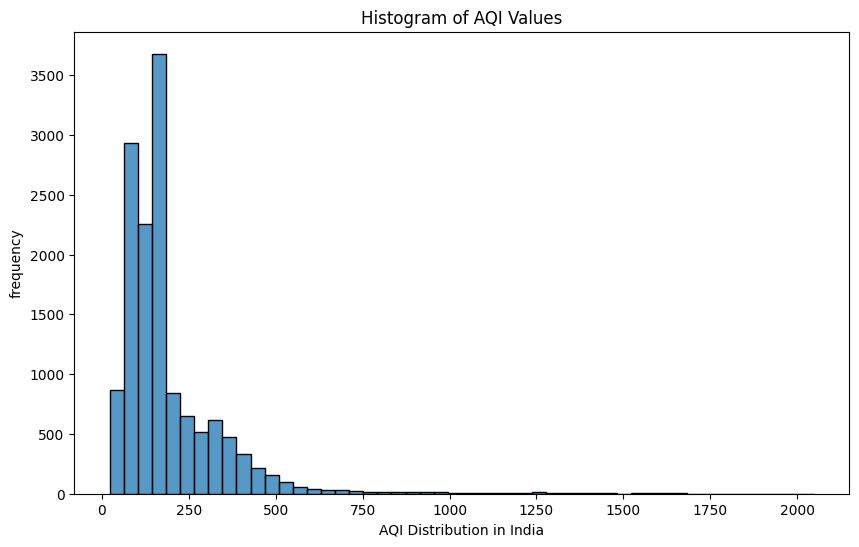

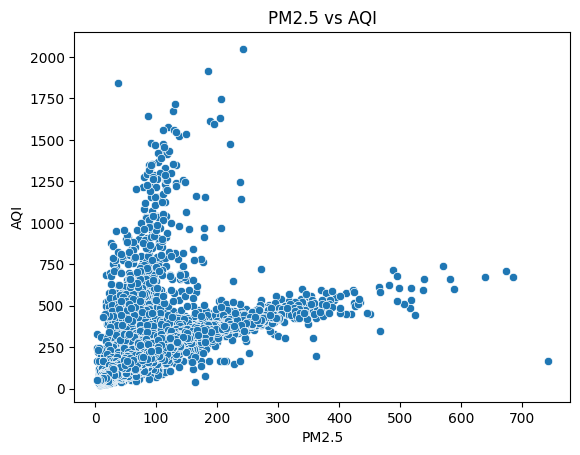

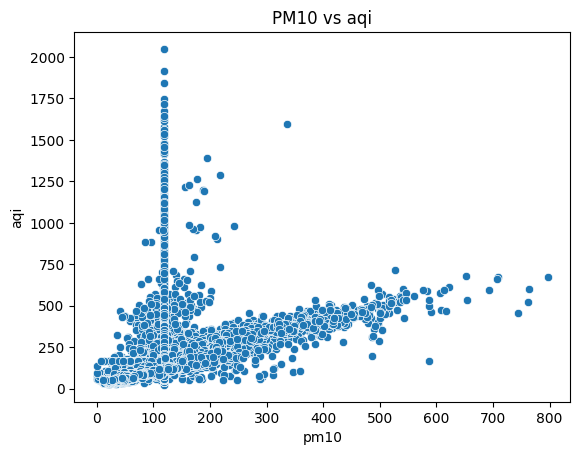

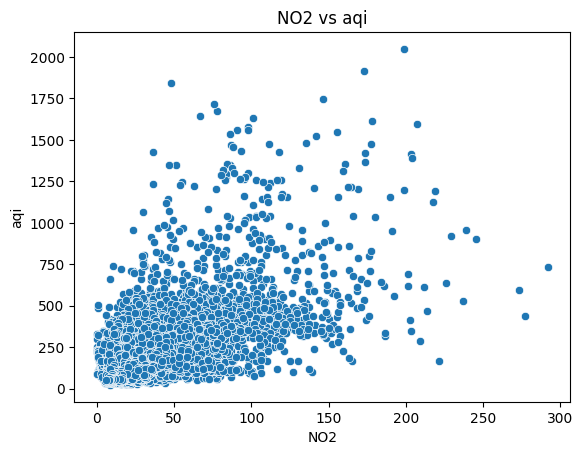

<Axes: >

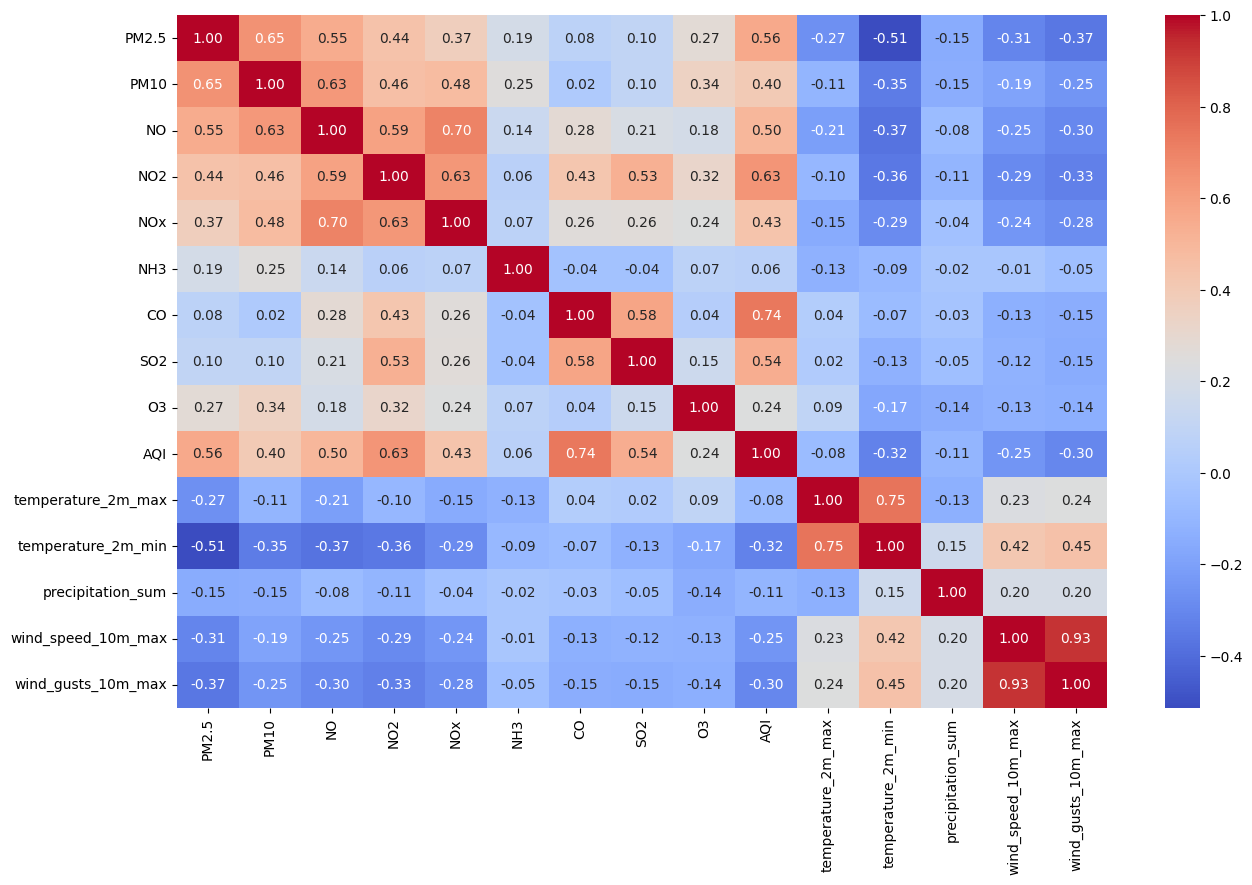

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
sns.histplot(merged['AQI'],bins=50)
#bin=ranges...1-5-,50-100...
plt.xlabel("AQI Distribution in India")
plt.ylabel("frequency")
plt.title("Histogram of AQI Values")
plt.show()
sns.scatterplot(x='PM2.5', y='AQI', data=merged)
plt.title("PM2.5 vs AQI")
plt.xlabel("PM2.5")
plt.ylabel("AQI")
plt.show()
sns.scatterplot(x='PM10',y='AQI',data=merged)
plt.title('PM10 vs aqi')
plt.xlabel("pm10")
plt.ylabel('aqi')
plt.show()
sns.scatterplot(x='NO2',y='AQI',data=merged)
plt.title('NO2 vs aqi')
plt.xlabel("NO2")
plt.ylabel('aqi')
plt.show()
plt.figure(figsize=(15,9))
sns.heatmap(merged.select_dtypes('number').corr(),annot=True,cmap='coolwarm',fmt='.2f')



In [6]:

from sklearn.model_selection import train_test_split
features=['PM2.5','PM10','NO2','SO2','CO','O3','temperature_2m_min','precipitation_sum','wind_gusts_10m_max']
x=merged[features]
y=merged['AQI']
print(x.head())
print(y.head())
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)
print("\nTraining X:", x_train.shape)
print("Testing X:", x_test.shape)

print("\nTraining y:", y_train.shape)
print("Testing y:", y_test.shape)

       PM2.5        PM10    NO2    SO2     CO      O3  temperature_2m_min  \
0  67.450578  118.127103  18.22  27.64   0.92  133.36                16.9   
1  67.450578  118.127103  15.69  24.55   0.97   34.06                17.3   
2  67.450578  118.127103  19.30  29.07  17.40   30.70                15.1   
3  67.450578  118.127103  18.48  18.59   1.70   36.08                14.5   
4  67.450578  118.127103  21.42  39.33  22.10   39.31                13.7   

   precipitation_sum  wind_gusts_10m_max  
0                0.0                29.9  
1                0.0                32.0  
2                0.0                24.8  
3                0.0                29.9  
4                0.0                31.0  
0    166.463581
1    166.463581
2    166.463581
3    166.463581
4    166.463581
Name: AQI, dtype: float64

Training X: (11183, 9)
Testing X: (2796, 9)

Training y: (11183,)
Testing y: (2796,)


In [8]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# create model
model = LinearRegression()

# train model
model.fit(x_train, y_train)

# predict AQI
y_pred = model.predict(x_test)

# evaluate
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("R2:", r2)

coefficients = pd.DataFrame({
    'Feature': x_train.columns,
    'Coefficient': model.coef_
})

coefficients = coefficients.sort_values(by='Coefficient', ascending=False)

print(coefficients)

MAE: 33.52545830563042
MSE: 4003.7382456392206
R2: 0.8301631384296695
              Feature  Coefficient
4                  CO     9.667274
0               PM2.5     1.146556
2                 NO2     0.757831
3                 SO2     0.753135
6  temperature_2m_min     0.378159
5                  O3     0.295998
1                PM10     0.098810
8  wind_gusts_10m_max    -0.006002
7   precipitation_sum    -0.042463


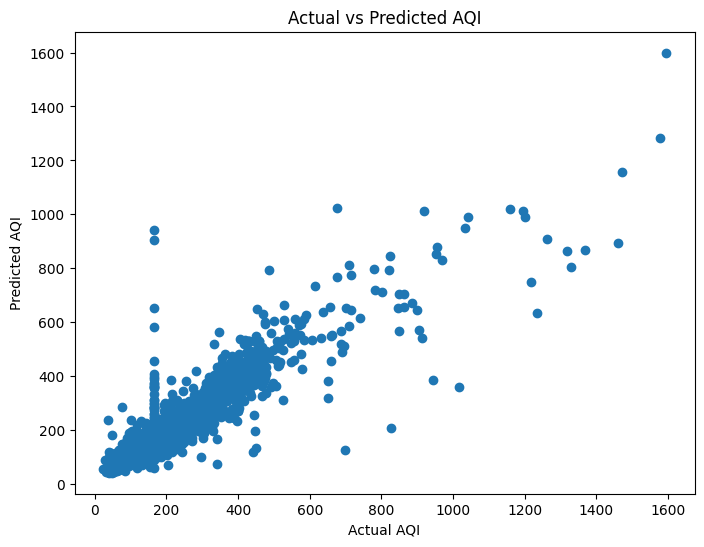

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred)

plt.xlabel("Actual AQI")
plt.ylabel("Predicted AQI")
plt.title("Actual vs Predicted AQI")

plt.show()

In [11]:
from sklearn.tree import DecisionTreeRegressor

# create model
tree_model = DecisionTreeRegressor(random_state=42)

# train
tree_model.fit(x_train, y_train)

# predict
tree_pred = tree_model.predict(x_test)

# evaluate
tree_mae = mean_absolute_error(y_test, tree_pred)
tree_mse = mean_squared_error(y_test, tree_pred)
tree_r2 = r2_score(y_test, tree_pred)

print("Decision Tree MAE:", tree_mae)
print("Decision Tree MSE:", tree_mse)
print("Decision Tree R2:", tree_r2)

Decision Tree MAE: 32.41482629683682
Decision Tree MSE: 5334.349422235957
Decision Tree R2: 0.7737191822220592


In [13]:
from sklearn.ensemble import RandomForestRegressor

# create model
rf_model = RandomForestRegressor(random_state=42)

# train
rf_model.fit(x_train, y_train)

# predict
rf_pred = rf_model.predict(x_test)

# evaluate
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_mse = mean_squared_error(y_test, rf_pred)
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest MAE:", rf_mae)
print("Random Forest MSE:", rf_mse)
print("Random Forest R2:", rf_r2)

Random Forest MAE: 23.056289054786543
Random Forest MSE: 2813.218668877438
Random Forest R2: 0.8806644689738139


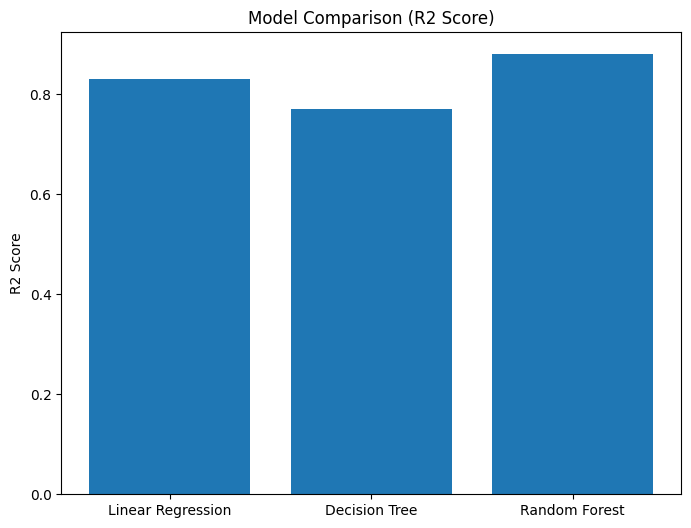

In [14]:
models = ['Linear Regression', 'Decision Tree', 'Random Forest']
r2_scores = [0.83, 0.77, 0.88]

plt.figure(figsize=(8,6))
plt.bar(models, r2_scores)

plt.title("Model Comparison (R2 Score)")
plt.ylabel("R2 Score")

plt.show()

In [ ]:
import joblib

joblib.dump(rf_model, "aqi_model.pkl")


['aqi_model.pkl']